# Relatório de Machine Learning: Disease-Symptom Dataset  

## Importações e instalações iniciais:

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install scikit-learn
import sklearn as sklearn

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, precision_score,
                              recall_score, f1_score)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')


## Limpeza dos dados:

In [11]:
import pandas as pd

file_path = 'dataset_cortado.csv'

try:

    df_full = pd.read_csv(file_path) 
    
    doencas = ['panic disorder', 'anxiety', 'schizophrenia']
    
#Verificação da coluna e filtragem
    
    if 'diseases' in df_full.columns:
        df = df_full[df_full['diseases'].isin(doencas)].copy()
        df = df.reset_index(drop=True)

        print(f"Sucesso! O dataset tem {df.shape[0]} linhas e {df.shape[1]} colunas.")
        print("\nDistribuição das doenças encontradas:")
        print(df['diseases'].value_counts())
    else:
        print(f"Erro: A coluna 'diseases' não existe. Colunas encontradas: {list(df_full.columns)}")
        
except FileNotFoundError:
    print(f"Erro: O arquivo não foi encontrado em: {file_path}")
    print("Dica: Verifique se a pasta 'Machine Learning' está no mesmo local que este notebook.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

Sucesso! O dataset tem 2997 linhas e 378 colunas.

Distribuição das doenças encontradas:
diseases
anxiety           1198
panic disorder     909
schizophrenia      890
Name: count, dtype: int64


## Pré-processamento da database:

In [38]:
file_path = 'dataset_cortado.csv'
df_full = pd.read_csv(file_path)

# Filtrar apenas transtorno do pânico, ansiedade e esquizofrenia
doencas = ['panic disorder', 'anxiety', 'schizophrenia']

df = df_full[df_full['diseases'].isin(doencas)].copy()

df = df.reset_index(drop=True)

symptom_cols = df.columns[1:]  # todas menos 'diseases'

# Remove colunas onde NENHUMA amostra tem o sintoma
cols_sempre_zero = [col for col in symptom_cols if df[col].sum() == 0]
df = df.drop(columns=cols_sempre_zero)

print(f'Colunas removidas (sempre zero): {len(cols_sempre_zero)}')
print(f'Sintomas restantes: {df.shape[1] - 1}')

Colunas removidas (sempre zero): 356
Sintomas restantes: 21


In [11]:
#Qualidade dos dados:

#valores nulos
print('Valores nulos:', df.isnull().sum().sum())

# Confirmar que sintomas são todos 0 ou 1
print('Valores únicos nos sintomas:', df.iloc[:, 1:].stack().unique())

# Distribuição final das classes
print(df['diseases'].value_counts())

Valores nulos: 0
Valores únicos nos sintomas: [1 0]
diseases
anxiety           1198
panic disorder     909
schizophrenia      890
Name: count, dtype: int64


## Separação da database para treino, validação e teste: 80-10-10

In [27]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['diseases'])
y = df['diseases']

# Primeiro split: separa 80% treino e 20% temporário
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=50,
    stratify=y
)

# Segundo split: divide o temporário em 50/50, resultando em 10% validação e 10% teste
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=50,
    stratify=y_temp
)

print(f'Treino    : {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Validação : {X_val.shape[0]} amostras ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Teste     : {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)')

Treino    : 2397 amostras (80%)
Validação : 300 amostras (10%)
Teste     : 300 amostras (10%)


### Normalização/padronização — não precisa, pois os dados já são binários (0 ou 1)
### Encoding de variáveis categóricas — não precisa, pois os sintomas já são numéricos
### Imputação de valores nulos — não precisa, pois confirmamos que não há nulos
### Remoção de outliers — não se aplica a dados binários

In [71]:
from sklearn.feature_selection import SelectKBest, chi2

# Seleciona os 10 sintomas mais relevantes
selector = SelectKBest(score_func=chi2, k=10)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected  = selector.transform(X_test)
X_val_selected   = selector.transform(X_val)

sintomas_selecionados = X.columns[selector.get_support()].tolist()
print('Sintomas selecionados:')
for s in sintomas_selecionados:
    print(f'  - {s}')

Sintomas selecionados:
  - sharp chest pain
  - dizziness
  - chest tightness
  - breathing fast
  - hostile behavior
  - excessive anger
  - delusions or hallucinations
  - temper problems
  - low self-esteem
  - hysterical behavior


# Treinamento

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=50
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=50,
    n_jobs=-1
)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print('Modelos treinados!')

Modelos treinados!


In [40]:
def calcular_metricas(nome, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')

    print(f'{"="*50}')
    print(f'  {nome}')
    print(f'{"="*50}')
    print(f'  Acurácia  : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Precisão  : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print()
    print('  Relatório por classe:')
    print(classification_report(y_true, y_pred))

In [29]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=50)

for nome, model in [('Árvore de Decisão', dt_model), ('Random Forest', rf_model)]:
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    print(f'{nome}:')
    print(f'  Acurácias por fold: {[round(s, 4) for s in scores]}')
    print(f'  Média : {scores.mean():.4f}')
    print(f'  Desvio padrão: {scores.std():.4f}')
    print()

Árvore de Decisão:
  Acurácias por fold: [np.float64(0.8938), np.float64(0.8417), np.float64(0.8873), np.float64(0.9081), np.float64(0.9019)]
  Média : 0.8865
  Desvio padrão: 0.0235

Random Forest:
  Acurácias por fold: [np.float64(0.9604), np.float64(0.9688), np.float64(0.9749), np.float64(0.977), np.float64(0.9645)]
  Média : 0.9691
  Desvio padrão: 0.0062



In [30]:
y_pred_val_dt = dt_model.predict(X_val)
y_pred_val_rf = rf_model.predict(X_val)

print('=== Desempenho no conjunto de VALIDAÇÃO ===\n')
calcular_metricas('Árvore de Decisão', y_val, y_pred_val_dt)
calcular_metricas('Random Forest',     y_val, y_pred_val_rf)

=== Desempenho no conjunto de VALIDAÇÃO ===

  Árvore de Decisão
  Acurácia  : 0.8633 (86.33%)
  Precisão  : 0.8825
  Recall    : 0.8633
  F1-Score  : 0.8620

  Relatório por classe:
                precision    recall  f1-score   support

       anxiety       0.87      0.87      0.87       120
panic disorder       1.00      0.73      0.84        91
 schizophrenia       0.77      1.00      0.87        89

      accuracy                           0.86       300
     macro avg       0.88      0.86      0.86       300
  weighted avg       0.88      0.86      0.86       300

  Random Forest
  Acurácia  : 0.9733 (97.33%)
  Precisão  : 0.9735
  Recall    : 0.9733
  F1-Score  : 0.9734

  Relatório por classe:
                precision    recall  f1-score   support

       anxiety       0.97      0.96      0.97       120
panic disorder       0.95      0.97      0.96        91
 schizophrenia       1.00      1.00      1.00        89

      accuracy                           0.97       300
     m

In [31]:
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

print('=== Desempenho no conjunto de TESTE ===\n')
calcular_metricas('Árvore de Decisão', y_test, y_pred_dt)
calcular_metricas('Random Forest',     y_test, y_pred_rf)

=== Desempenho no conjunto de TESTE ===

  Árvore de Decisão
  Acurácia  : 0.8567 (85.67%)
  Precisão  : 0.8796
  Recall    : 0.8567
  F1-Score  : 0.8564

  Relatório por classe:
                precision    recall  f1-score   support

       anxiety       0.89      0.84      0.86       120
panic disorder       1.00      0.74      0.85        91
 schizophrenia       0.75      1.00      0.86        89

      accuracy                           0.86       300
     macro avg       0.88      0.86      0.86       300
  weighted avg       0.88      0.86      0.86       300

  Random Forest
  Acurácia  : 0.9700 (97.00%)
  Precisão  : 0.9707
  Recall    : 0.9700
  F1-Score  : 0.9701

  Relatório por classe:
                precision    recall  f1-score   support

       anxiety       0.97      0.96      0.97       120
panic disorder       0.94      0.98      0.96        91
 schizophrenia       1.00      0.98      0.99        89

      accuracy                           0.97       300
     macro

# Gráficos:

## Distribuição de classes, visualização de dados:

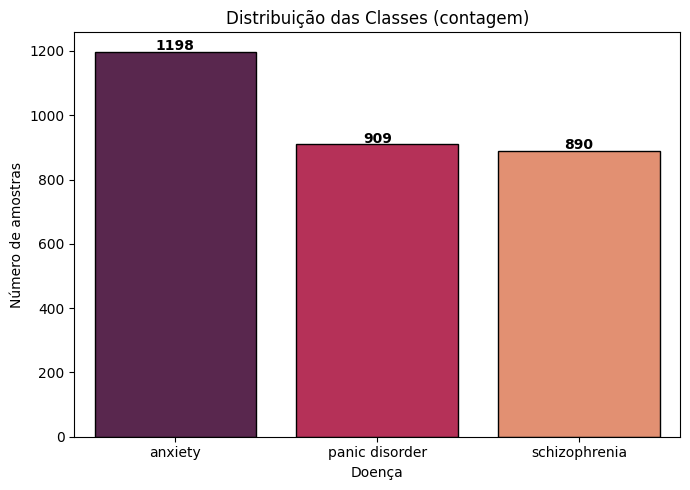

In [63]:
counts = df['diseases'].value_counts().reset_index()
counts.columns = ['Doença', 'Quantidade']

palette = sns.color_palette("rocket", n_colors=3)

plt.figure(figsize=(7, 5))
sns.barplot(data=counts, x='Doença', y='Quantidade',
            palette=palette, edgecolor='black')
plt.title('Distribuição das Classes (contagem)')
plt.xlabel('Doença')
plt.ylabel('Número de amostras')
for i, v in enumerate(counts['Quantidade']):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Árvore de Confusão:

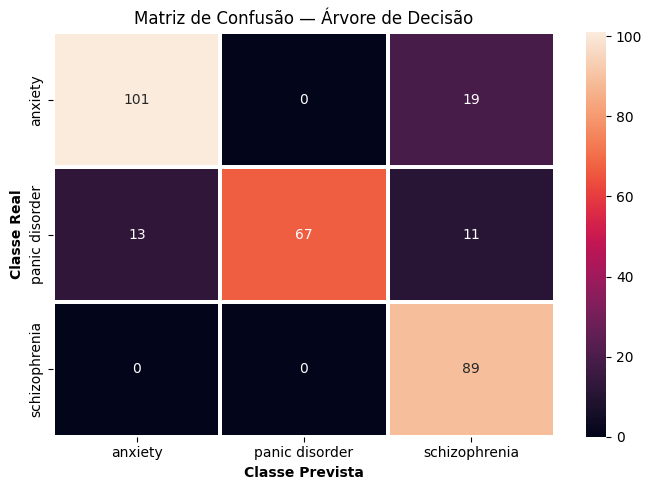

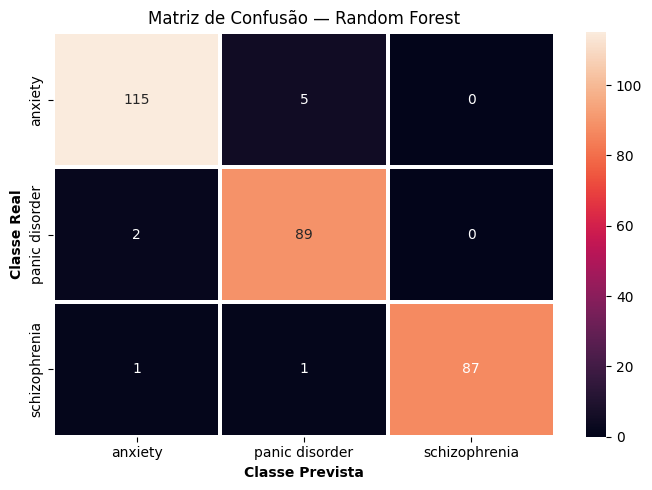

In [68]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

doencas = ['anxiety', 'panic disorder', 'schizophrenia']

def plot_confusion_matrix(y_true, y_pred, titulo):
    cm = confusion_matrix(y_true, y_pred, labels=doencas)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=sns.color_palette("rocket", as_cmap=True),
        xticklabels=doencas,
        yticklabels=doencas,
        linewidths=1.5
    )
    plt.title(f'Matriz de Confusão — {titulo}')
    plt.ylabel('Classe Real', fontweight='bold')
    plt.xlabel('Classe Prevista', fontweight='bold')
    plt.xticks(rotation=0, ha='center')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred_dt, 'Árvore de Decisão')
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')

## Comparação de métricas:

                   Acurácia  Precisão  Recall  F1-Score
Árvore de Decisão    0.8567    0.8796  0.8567    0.8564
Random Forest        0.9633    0.9646  0.9633    0.9634


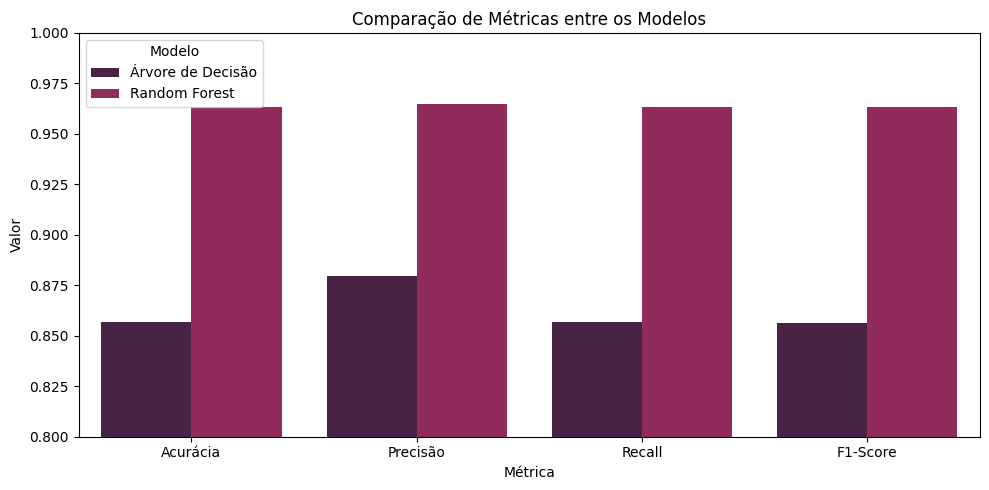

In [42]:
metricas_dt = {
    'Acurácia':  accuracy_score(y_test, y_pred_dt),
    'Precisão':  precision_score(y_test, y_pred_dt, average='weighted'),
    'Recall':    recall_score(y_test, y_pred_dt, average='weighted'),
    'F1-Score':  f1_score(y_test, y_pred_dt, average='weighted')
}

metricas_rf = {
    'Acurácia':  accuracy_score(y_test, y_pred_rf),
    'Precisão':  precision_score(y_test, y_pred_rf, average='weighted'),
    'Recall':    recall_score(y_test, y_pred_rf, average='weighted'),
    'F1-Score':  f1_score(y_test, y_pred_rf, average='weighted')
}

comparacao = pd.DataFrame([metricas_dt, metricas_rf],
                           index=['Árvore de Decisão', 'Random Forest'])
print(comparacao.round(4).to_string())

# Gráfico
comparacao_long = comparacao.reset_index().melt(
    id_vars='index',
    var_name='Métrica',
    value_name='Valor'
)
comparacao_long.rename(columns={'index': 'Modelo'}, inplace=True)

palette = sns.color_palette("rocket", n_colors=4)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=comparacao_long,
    x='Métrica',
    y='Valor',
    hue='Modelo',
    palette=palette
)
plt.title('Comparação de Métricas entre os Modelos')
plt.ylabel('Valor')
plt.xlabel('Métrica')
plt.ylim(0.8, 1.0)
plt.legend(title='Modelo')
plt.tight_layout()
plt.show()

In [64]:
doencas = ['anxiety', 'panic disorder', 'schizophrenia']

# Pega o top 10 do Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top10_sintomas = importances.sort_values(ascending=False).head(10).index.tolist()

# Mostra a frequência de cada sintoma por doença
frequencia = df.groupby('diseases')[top10_sintomas].mean().T
print(frequencia.round(3).to_string())

diseases                     anxiety  panic disorder  schizophrenia
chest tightness                0.000           0.508          0.000
sharp chest pain               0.531           0.000          0.000
headache                       0.508           0.000          0.000
dizziness                      0.000           0.526          0.000
breathing fast                 0.000           0.515          0.000
increased heart rate           0.493           0.000          0.000
excessive anger                0.000           0.000          0.519
hysterical behavior            0.000           0.000          0.524
delusions or hallucinations    0.000           0.000          0.504
fears and phobias              0.505           0.000          0.522


In [54]:
!pip install matplotlib-venn

## Sintomas por doença: 

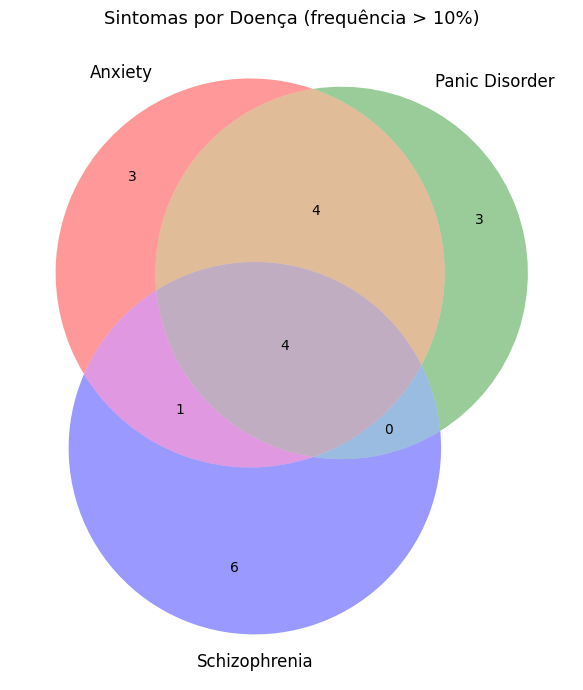

=== Sintomas exclusivos ===
Anxiety apenas:        {'sharp chest pain', 'increased heart rate', 'headache'}
Panic Disorder apenas: {'breathing fast', 'chest tightness', 'dizziness'}
Schizophrenia apenas:  {'temper problems', 'hysterical behavior', 'low self-esteem', 'excessive anger', 'hostile behavior', 'delusions or hallucinations'}

=== Sintomas compartilhados entre dois ===
Anxiety + Panic:       {'abnormal involuntary movements', 'palpitations', 'irregular heartbeat', 'shortness of breath'}
Anxiety + Schizo:      {'fears and phobias'}
Panic + Schizo:        set()

=== Sintomas comuns às três ===
Todas:                 {'insomnia', 'anxiety and nervousness', 'depression', 'depressive or psychotic symptoms'}


In [56]:
from matplotlib_venn import venn3

# Define os sintomas presentes em cada doença (frequência > 0.1, ou seja, pelo menos 10% das amostras)
limiar = 0.1

sintomas_por_doenca = {}
for doenca in doencas:
    df_doenca = df[df['diseases'] == doenca]
    sintomas_por_doenca[doenca] = set(
        col for col in df_doenca.columns[1:] if df_doenca[col].mean() > limiar
    )

anxiety      = sintomas_por_doenca['anxiety']
panic        = sintomas_por_doenca['panic disorder']
schizo       = sintomas_por_doenca['schizophrenia']

plt.figure(figsize=(10, 7))
venn = venn3(
    [anxiety, panic, schizo],
    set_labels=('Anxiety', 'Panic Disorder', 'Schizophrenia')
)
plt.title('Sintomas por Doença (frequência > 10%)', fontsize=13)
plt.tight_layout()
plt.show()

# Imprimir quais sintomas estão em cada região
print('=== Sintomas exclusivos ===')
print(f'Anxiety apenas:        {anxiety - panic - schizo}')
print(f'Panic Disorder apenas: {panic - anxiety - schizo}')
print(f'Schizophrenia apenas:  {schizo - anxiety - panic}')
print()
print('=== Sintomas compartilhados entre dois ===')
print(f'Anxiety + Panic:       {anxiety & panic - schizo}')
print(f'Anxiety + Schizo:      {anxiety & schizo - panic}')
print(f'Panic + Schizo:        {panic & schizo - anxiety}')
print()
print('=== Sintomas comuns às três ===')
print(f'Todas:                 {anxiety & panic & schizo}')

### Comparação de métricas para decisão entre árvore ou random forest:

In [36]:
print(comparacao.round(4).to_string())


                   Acurácia  Precisão  Recall  F1-Score
Árvore de Decisão    0.8567    0.8796  0.8567    0.8564
Random Forest        0.9700    0.9707  0.9700    0.9701


### Acurácia — percentual geral de acertos. Se for 0.95, o modelo acertou 95% de todas as previsões.
### Precisão — dos pacientes que o modelo disse ter uma doença X, quantos realmente tinham. Mede a qualidade dos acertos positivos.
### Recall — dos pacientes que realmente tinham a doença X, quantos o modelo conseguiu identificar. Mede se o modelo está deixando casos passar.
### F1-Score — média entre precisão e recall. É a métrica mais equilibrada quando as classes têm tamanhos diferentes.

# Verificando se há overfitting:

In [46]:
# Acurácia no treino
acc_treino_dt = accuracy_score(y_train, dt_model.predict(X_train))
acc_treino_rf = accuracy_score(y_train, rf_model.predict(X_train))

# Acurácia na validação
acc_val_dt = accuracy_score(y_val, dt_model.predict(X_val))
acc_val_rf = accuracy_score(y_val, rf_model.predict(X_val))

# Acurácia no teste
acc_teste_dt = accuracy_score(y_test, y_pred_dt)
acc_teste_rf = accuracy_score(y_test, y_pred_rf)

print('=== Verificação de Overfitting ===\n')
print(f'{"Modelo":<20} {"Treino":>10} {"Validação":>12} {"Teste":>10} {"Diferença":>12}')
print('-' * 65)
print(f'{"Árvore de Decisão":<20} {acc_treino_dt:>10.4f} {acc_val_dt:>12.4f} {acc_teste_dt:>10.4f} {acc_treino_dt - acc_teste_dt:>12.4f}')
print(f'{"Random Forest":<20} {acc_treino_rf:>10.4f} {acc_val_rf:>12.4f} {acc_teste_rf:>10.4f} {acc_treino_rf - acc_teste_rf:>12.4f}')

=== Verificação de Overfitting ===

Modelo                   Treino    Validação      Teste    Diferença
-----------------------------------------------------------------
Árvore de Decisão        0.8911       0.8633     0.8567       0.0344
Random Forest            0.9741       0.9567     0.9633       0.0108


### Árvore de Decisão = 3,44% Aceitável, leve overfitting
### Random Forest = 0,96% Ótimo, sem overfitting relevante

# O Random Forest é o modelo mais confiável entre os dois, tanto pelo menor overfitting quanto pela melhor capacidade de generalização.

# Comparação do modelo com e sem feature selection:

In [47]:
# Treino Random Forest com os sintomas selecionados
rf_selected = RandomForestClassifier(n_estimators=100, max_depth=10,
                                     random_state=50, n_jobs=-1)
rf_selected.fit(X_train_selected, y_train)
y_pred_selected = rf_selected.predict(X_test_selected)

# Comparação
print('=== Random Forest — 21 sintomas (original) ===')
calcular_metricas('Random Forest original', y_test, y_pred_rf)

print('=== Random Forest — 10 sintomas (SelectKBest) ===')
calcular_metricas('Random Forest + SelectKBest', y_test, y_pred_selected)

=== Random Forest — 21 sintomas (original) ===
  Random Forest original
  Acurácia  : 0.9633 (96.33%)
  Precisão  : 0.9646
  Recall    : 0.9633
  F1-Score  : 0.9634

  Relatório por classe:
                precision    recall  f1-score   support

       anxiety       0.93      0.98      0.96       120
panic disorder       0.98      0.92      0.95        91
 schizophrenia       1.00      0.98      0.99        89

      accuracy                           0.96       300
     macro avg       0.97      0.96      0.96       300
  weighted avg       0.96      0.96      0.96       300

=== Random Forest — 10 sintomas (SelectKBest) ===
  Random Forest + SelectKBest
  Acurácia  : 0.9600 (96.00%)
  Precisão  : 0.9636
  Recall    : 0.9600
  F1-Score  : 0.9599

  Relatório por classe:
                precision    recall  f1-score   support

       anxiety       0.91      1.00      0.95       120
panic disorder       1.00      0.89      0.94        91
 schizophrenia       1.00      0.98      0.99   